# Genes mirror geography — PCA on 2,504 human genomes

**Instructor-led practical, chapter 10.** In 2008, Novembre et al. ran plain PCA on the DNA of
~1,400 Europeans and the scatter of PC1 vs PC2 came out looking like **the map of Europe** (the published axes are rotated $-16^\circ$ to line up with geography - the structure is PCA's, the orientation is the authors')
([*Genes mirror geography within Europe*, Nature 2008](https://www.ncbi.nlm.nih.gov/pmc/articles/PMC2735096/)).
Nobody told the algorithm anything about geography.

Today we reproduce that idea on fully open data: **1000 Genomes phase 3**, 2,504 people from 26
populations, using only **chromosome 22** and only the tools from the lecture. Everything loads
from `data/genomes_1000g_chr22.npz` — numpy, no bioinformatics stack.
([population codes](https://ftp.1000genomes.ebi.ac.uk/vol1/ftp/README_populations.md))

In [1]:
import os, sys, time
for v in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS", "NUMEXPR_NUM_THREADS"):
    os.environ.setdefault(v, "4")          # keep the laptop usable

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score

SEED = 509
rng = np.random.default_rng(SEED)
sys.path.insert(0, str(Path.cwd()))        # for the given py_src helpers
from py_src.genes_geography_maps import (coastlines, draw_map, SITES,
                                         SUPER_COLORS, SUPER_NAMES, EUR_NAMES)

d = np.load("data/genomes_1000g_chr22.npz", allow_pickle=True)
X, pop, sup = d["genotypes"], d["pop"], d["super_pop"]
print(f"genotype matrix: {X.shape[0]} people x {X.shape[1]} SNPs, dtype {X.dtype}")
for s in sorted(set(sup)):
    print(f"  {s} - {SUPER_NAMES[s]:<12} {(sup == s).sum():>4} people")
print("source:", str(d["source"]))

genotype matrix: 2504 people x 16202 SNPs, dtype int8
  AFR - African       661 people
  AMR - American      347 people
  EAS - East Asian    504 people
  EUR - European      503 people
  SAS - South Asian   489 people
source: http://ftp.1000genomes.ebi.ac.uk/vol1/ftp/release/20130502/ALL.chr22.phase3_shapeit2_mvncall_integrated_v5b.20130502.genotypes.vcf.gz


## Act 0 - what is this matrix, actually?

Your genome is a text of ~3.2 billion letters (A, C, G, T) - and you carry **two copies** of
it, one from each parent. Between any two people those texts agree almost everywhere; a
**SNP** (*single-nucleotide polymorphism*) is a position where humans are known to differ by
a single letter. So at one SNP a person collapses to one small number - **how many of their
two copies carry the *alternate* letter: 0, 1, or 2**. That count is the entire data model:

- a **row is a person** - a real, consented volunteer with an ID (`HG00096` is a British
  participant from the GBR sample);
- a **column is a SNP** - a real position on chromosome 22, like `chr22:16,053,659`;
- the **value** is that person's alternate-letter count at that position.

We kept only *common* variants (alternate-letter frequency 5-95% across the 2,504 people,
and then every 6th one along the chromosome): a rare variant is individually too noisy to
help a PCA of this size, and the frequency scaling in Act 1 would blow it up.

That makes this the widest dataset of the course so far - **16,202 features for 2,504
samples**, the curse-of-dimensionality frame with people as the rows. Here is its top-left
corner with the real labels on:


In [2]:
import pandas as pd

corner = pd.DataFrame(X[:5, :6],
                      index=[f"{s}  ({p})" for s, p in zip(d["samples"][:5], pop[:5])],
                      columns=[f"chr22:{q:,}" for q in d["pos"][:6]])
display(corner)

for v, c in zip(*np.unique(X, return_counts=True)):
    print(f"value {v}: {c / X.size:.1%} of the matrix")


value 0: 54.8% of the matrix
value 1: 28.1% of the matrix
value 2: 17.0% of the matrix


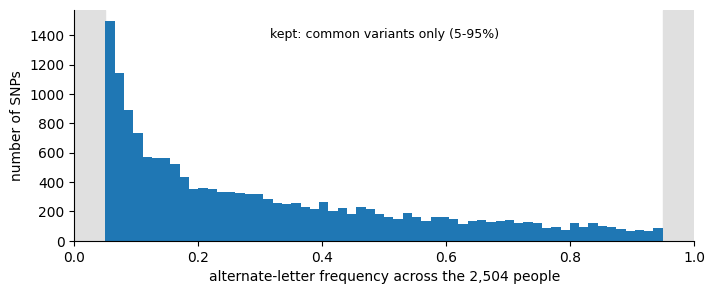

In [3]:
fig, ax = plt.subplots(figsize=(8.0, 3.0))
ax.hist(d["af"], bins=60, color="tab:blue")
for lo, hi in ((0, 0.05), (0.95, 1)):
    ax.axvspan(lo, hi, color="0.88", zorder=0)
ax.text(0.5, 0.88, "kept: common variants only (5-95%)", transform=ax.transAxes,
        ha="center", fontsize=9)
ax.set_xlim(0, 1)
ax.set_xlabel("alternate-letter frequency across the 2,504 people")
ax.set_ylabel("number of SNPs")
ax.spines[["top", "right"]].set_visible(False)
plt.show()


**Reading the histogram:** a SNP's *alternate-letter frequency* is the share of all
$2{,}504 \times 2 = 5{,}008$ genome copies in the room that carry the alternate letter -
a share, so by definition it lives between 0 and 1. The grey bands mark what we excluded
up front: variants rarer than 5% or commoner than 95%.

Three honest reads before any algorithm touches this:

1. **The matrix is mostly zeros** (55% - see the counts above): at a typical position, most
   people carry no alternate letter at all. A *single* column splits humanity into three
   bins and says nearly nothing about anyone.
2. Even the kept "common" variants pile up toward the rare edge (histogram above; more than
   half sit below 25% frequency) - so most columns are *weak*.
3. If there is structure here, it must live **spread thinly across thousands of weak
   columns**. Finding a few directions that collect it is exactly the job PCA was built for.

**Predict first:** if PCA ranks directions by variance - what will PC1 of humanity *be*?


## Act 1 — PCA of raw genotype counts

One scaling decision first, exactly the lecture's scaling-trap frame: all columns are already in
the *same units* (0/1/2), so centering is mandatory, standardizing is a **choice**. Population
genetics has its own convention — divide each SNP by $\sqrt{p(1-p)}$ - the standard deviation of a single allele draw (Patterson et al. 2006). Let's measure whether it matters here.

"Matters" needs a number. We reuse ch09's **silhouette score**, backwards: instead of
scoring clusters an algorithm found, we hand it the *known* five super-population labels
and ask how separated those groups are in the first two PC scores - near **+1** means
tight, well-separated groups, near **0** touching, **negative** mixed together. One
number per scaling variant, then compare.

In [4]:
def pca_scores(X, n=10, patterson=True):
    """Center each SNP; optionally scale by sqrt(p(1-p)) (Patterson et al. 2006)."""
    X = X.astype(np.float32)
    p = X.mean(axis=0) / 2.0                  # allele frequency per SNP
    Xc = X - 2.0 * p
    if patterson:
        Xc /= np.sqrt(p * (1.0 - p))
    pca = PCA(n_components=n, random_state=SEED)
    return pca.fit_transform(Xc), pca.explained_variance_ratio_

for patterson in (False, True):
    Z, evr = pca_scores(X, patterson=patterson)
    sil = silhouette_score(Z[:, :2], sup)
    print(f"patterson={patterson!s:<5}  EVR(PC1, PC2) = {evr[0]:.3f}, {evr[1]:.3f}   "
          f"silhouette of 5 super-pops on PC1-2 = {sil:.3f}")

Z, evr = pca_scores(X)   # Patterson scaling from here on

patterson=False  EVR(PC1, PC2) = 0.101, 0.045   silhouette of 5 super-pops on PC1-2 = 0.574


patterson=True   EVR(PC1, PC2) = 0.102, 0.041   silhouette of 5 super-pops on PC1-2 = 0.588


Barely any difference (0.574 vs 0.588) — when the structure is this strong, the scaling knob
stops mattering. Now the answer to the predict-first question, with the sampling map alongside:

*(Plot mechanics, so nothing is magic: `draw_map` draws the public-domain Natural Earth
coastline polylines with plain `plt.plot` - no geo stack; `SITES` is a hand-entered
city-level lon/lat per population; `SUPER_COLORS` pins one fixed color per continental
group, and every plot in this practical reuses it.)*

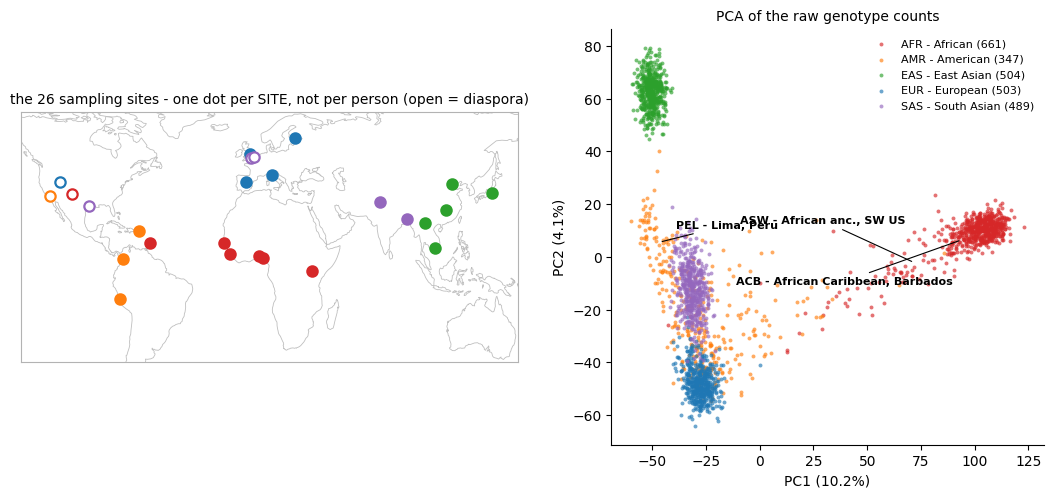

In [5]:
lines = coastlines()
fig, (axm, axp) = plt.subplots(1, 2, figsize=(13.2, 5.4), gridspec_kw={"width_ratios": [1.15, 1]})
draw_map(axm, lines, (-135, 155, -40, 72))
for c26, (lon, lat, diaspora) in SITES.items():
    col = SUPER_COLORS[sup[pop == c26][0]]
    axm.scatter(lon, lat, s=55, color="white" if diaspora else col, edgecolors=col,
                linewidths=1.6, zorder=3)
axm.set_title("the 26 sampling sites - one dot per SITE, not per person (open = diaspora)",
              fontsize=10)

for s in sorted(SUPER_NAMES):
    m = sup == s
    axp.scatter(Z[m, 0], Z[m, 1], s=8, alpha=0.65, color=SUPER_COLORS[s], linewidths=0,
                label=f"{s} - {SUPER_NAMES[s]} ({m.sum()})")
admix = {"PEL": ("PEL - Lima, Peru", (12, 10), "left"),          # name the admixture,
         "ASW": ("ASW - African anc., SW US", (-6, 28), "right"),  # don't recolor it
         "ACB": ("ACB - African Caribbean, Barbados", (-6, -32), "right")}
for c26, (label, off, ha) in admix.items():
    med = np.median(Z[pop == c26, :2], axis=0)
    axp.annotate(label, med, textcoords="offset points", xytext=off, fontsize=8, ha=ha,
                 fontweight="bold", arrowprops=dict(arrowstyle="-", lw=0.8))
axp.set_xlabel(f"PC1 ({evr[0]*100:.1f}%)"); axp.set_ylabel(f"PC2 ({evr[1]*100:.1f}%)")
axp.set_title("PCA of the raw genotype counts", fontsize=10)
axp.legend(frameon=False, fontsize=8, loc="upper right")
axp.spines[["top", "right"]].set_visible(False)
plt.show()

**PC1 of humanity is ancestry** — the two largest directions of variance in these 16,202
columns separate the five continental groups. And read the **smears**: the AMR populations (orange - Lima, Mexican-ancestry LA, Puerto Rico, Medellin) and the African-diaspora samples (ASW, ACB - colored AFR **red**, trailing toward the other clusters) are *admixed*, and their genomes really are continuous mixtures - the smears are not noise, they are history. Hold that thought for Act 4.

Also note what PCA did **not** need: no labels, no geography, no model of migration. Variance
alone. (And note the diaspora samples on the map — the open, outline-only circles: sampled in Utah, Houston, the UK — sit with
their *ancestry* in the PCA, not with their address.)

One preview of Act 2's lesson: the five *tidy clusters* are partly a sampling artifact themselves - 1000G sampled 26 distinct populations far apart, with nobody from the Middle East, North Africa, Central Asia or Oceania. Sample the in-betweens and the gaps would fill with gradients. (An Armenian sample, for instance, would land squarely in one of those gaps.)

## Act 2 - PCA by hand: the whole lecture in four lines of numpy

`PCA()` is not magic - the deck derived it: center, form the covariance matrix $\Sigma$,
take its top eigenvectors ($\Sigma\,w = \lambda\,w$), project. numpy has every step, so
let's run the math ourselves, then check sklearn against it.

One practical wrinkle: $\Sigma$ is $d \times d$. For all 16,202 SNPs that is a
$16{,}202^2$ matrix - about **2 GB** of RAM and a long eigendecomposition - which is
precisely why real implementations go through the SVD instead (the deck's "SVD connection"
frame: same answer, $\Sigma$ never built). For the by-hand version we take every 8th SNP,
so $\Sigma$ is $2{,}026 \times 2{,}026$ and fits in 33 MB.

To be clear about what that subsample does: 2,026 SNPs is a *coarser dataset* than
16,202, and its scores are **not** identical to Act 1's - the continents still show,
because the ancestry signal is smeared redundantly across thousands of common SNPs, but
the picture is a little blurrier. The equality this act demonstrates is **by-hand vs
library on the same matrix**, not subsample vs full.


**Why is the covariance matrix just $X_c^\top X_c\,/\,n$?** By definition
$\Sigma_{jk} = \frac{1}{n}\sum_i (x_{ij}-\bar{x}_j)(x_{ik}-\bar{x}_k)$. On *centered* data
every column mean $\bar{x}_j$ is zero, so this collapses to
$\Sigma_{jk} = \frac{1}{n}\sum_i x_{ij}\,x_{ik}$ - and "sum over samples of (column $j$
entry) times (column $k$ entry)" is exactly entry $(j,k)$ of the matrix product
$X_c^\top X_c$. One matrix multiply computes every variance (the diagonal) and every
covariance (the off-diagonals) at once - the deck's covariance-refresher frame as one line
of code.


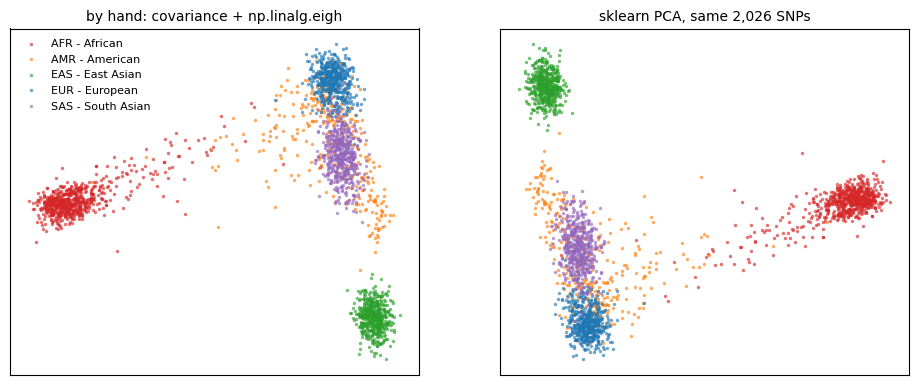

explained variance   eigh: 0.1010, 0.0410   svd: 0.1010, 0.0410   sklearn: 0.1010, 0.0410
eigh vs svd    : per-axis sign [-1  1],  max |score difference| after matching signs 7.2e-05
eigh vs sklearn: per-axis sign [-1 -1],  max |score difference| after matching signs 5.7e-05


In [6]:
Xsub = X[:, ::8].astype(np.float32)              # every 8th SNP -> 2,026 columns
p8 = Xsub.mean(axis=0) / 2
Xc8 = (Xsub - 2 * p8) / np.sqrt(p8 * (1 - p8))   # Act 1's Patterson scaling, verbatim

# --- PCA by hand ----------------------------------------------------------
Sigma = (Xc8.T @ Xc8) / len(Xc8)          # 1. covariance matrix (data is centered)
lam, V = np.linalg.eigh(Sigma)            # 2. its eigenvalues / eigenvectors (ascending)
lam, V = lam[::-1], V[:, ::-1]            # 3. re-sort descending, like the deck
Z_hand = Xc8 @ V[:, :2]                   # 4. project onto the top-2 eigenvectors
# --------------------------------------------------------------------------

# --- the same thing through the SVD (the deck's "SVD connection" frame) ---
U, S, Vt = np.linalg.svd(Xc8, full_matrices=False)   # X_c = U S V^T   (~10 s)
Z_svd = U[:, :2] * S[:2]                             # scores Z = US
lam_svd = S**2 / len(Xc8)                            # eigenvalues from singular values
# --------------------------------------------------------------------------

skl = PCA(n_components=2, svd_solver="full", random_state=SEED).fit(Xc8)
Z_skl = skl.transform(Xc8)

fig, axes = plt.subplots(1, 2, figsize=(11.6, 4.5))
for ax, Zx, t in ((axes[0], Z_hand, "by hand: covariance + np.linalg.eigh"),
                  (axes[1], Z_skl, "sklearn PCA, same 2,026 SNPs")):
    for s in sorted(SUPER_NAMES):
        m = sup == s
        ax.scatter(Zx[m, 0], Zx[m, 1], s=6, alpha=0.65, color=SUPER_COLORS[s],
                   linewidths=0, label=f"{s} - {SUPER_NAMES[s]}")
    ax.set_title(t, fontsize=10); ax.set_xticks([]); ax.set_yticks([])
axes[0].legend(frameon=False, fontsize=8)
plt.show()

print(f"explained variance   eigh: {lam[0]/lam.sum():.4f}, {lam[1]/lam.sum():.4f}"
      f"   svd: {lam_svd[0]/lam_svd.sum():.4f}, {lam_svd[1]/lam_svd.sum():.4f}"
      f"   sklearn: {skl.explained_variance_ratio_[0]:.4f}, {skl.explained_variance_ratio_[1]:.4f}")
for name, Zx in (("svd", Z_svd), ("sklearn", Z_skl)):
    flip = np.sign((Z_hand * Zx).sum(axis=0))    # a PC is only defined up to +/-
    print(f"eigh vs {name:<7}: per-axis sign {flip.astype(int)},  "
          f"max |score difference| after matching signs {np.abs(Z_hand * flip - Zx).max():.1e}")


All three agree: the same explained-variance ratios, the same scores to about $10^{-4}$
(float32 rounding) - and panels can come out mirrored, because an eigenvector is only defined
**up to sign** ($\Sigma(-w) = \lambda(-w)$) and each implementation picks its own. That is
why two "identical" PCA plots from different tools can look flipped.

The SVD route is the deck's "SVD connection" frame, live: $X_c = USV^\top$ gives the scores
as $Z = US$ and the eigenvalues as $\lambda_i = \sigma_i^2/n$ - the same numbers, with
$\Sigma$ never built. That is essentially what sklearn runs: stabler, no $d \times d$
matrix, a fast randomized solver for wide data - and it *remembers* the axes, so `transform`
can place new people onto them later (Act 5 does exactly that with its 500 held-out test
people). But nothing inside it is beyond the lecture's math: **covariance, eigenvectors,
project.**


## Act 3 — Europe only. Predict first: these 503 people are all one color above. Does PCA see *anything* inside?

In [7]:
eur = sup == "EUR"
try:
    Ze, evr_e = pca_scores(X[eur])
except ValueError as e:
    print("PCA refused the matrix:", str(e).splitlines()[0])

PCA refused the matrix: Input X contains NaN.


C:\Users\hayk_\AppData\Local\Temp\ipykernel_16028\1507455135.py:7: RuntimeWarning: invalid value encountered in divide
  Xc /= np.sqrt(p * (1.0 - p))


In [8]:
# Diagnose it ourselves. p(1-p) hit zero somewhere:
p_eur = X[eur].astype(np.float32).mean(axis=0) / 2
mono = (p_eur == 0) | (p_eur == 1)
print(f"{mono.sum()} of {len(p_eur)} SNPs are monomorphic WITHIN Europe -")
print("common somewhere in the world, but every European carries the same genotype.")
print("Zero variance in this subset -> sqrt(p(1-p)) = 0 -> division by zero -> NaN.")

323 of 16202 SNPs are monomorphic WITHIN Europe -
common somewhere in the world, but every European carries the same genotype.
Zero variance in this subset -> sqrt(p(1-p)) = 0 -> division by zero -> NaN.


(numpy's red `RuntimeWarning` above was the first clue: *invalid value encountered in divide*.)

This is a *general* PCA lesson, not a genetics quirk: **subset your data and features can go
constant** — and any per-feature scaling then divides by zero. The fix is explicit and loud:

dropping 323 SNPs monomorphic in this subset


median PC1/PC2  CEU: [-1.6 -0.2]
median PC1/PC2  FIN: [-3.  27.6]
median PC1/PC2  GBR: [-7.1  1. ]
median PC1/PC2  IBS: [ -6.8 -12.1]
median PC1/PC2  TSI: [ -6.2 -11.7]


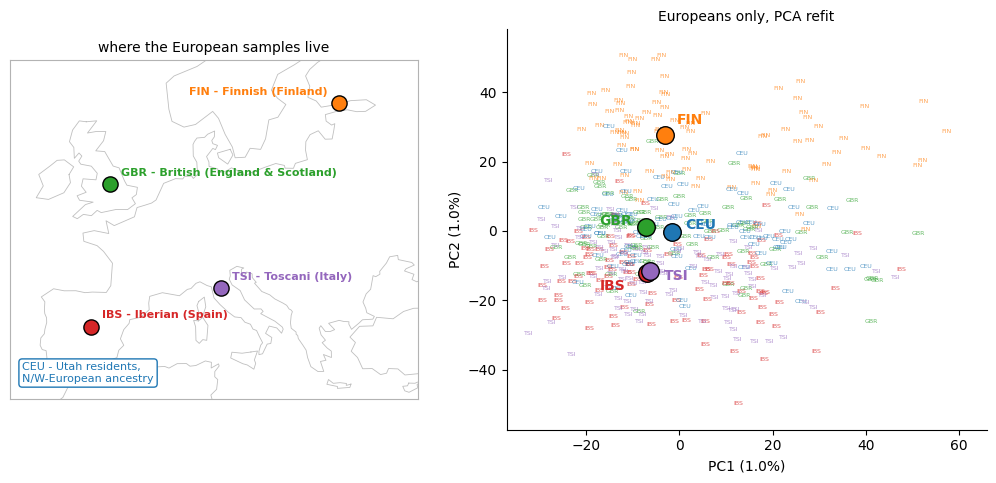

In [9]:
def pca_scores_safe(X, n=10):
    """Patterson-scaled PCA that DROPS features with zero variance in this subset - loudly."""
    X = X.astype(np.float32)
    p = X.mean(axis=0) / 2.0
    keep = (p > 0) & (p < 1)
    if not keep.all():
        print(f"dropping {(~keep).sum()} SNPs monomorphic in this subset")
        X, p = X[:, keep], p[keep]
    Xc = (X - 2.0 * p) / np.sqrt(p * (1.0 - p))
    pca = PCA(n_components=n, random_state=SEED)
    return pca.fit_transform(Xc), pca.explained_variance_ratio_

Ze, evr_e = pca_scores_safe(X[eur])
pe = pop[eur]

cmap = dict(zip(sorted(set(pe)), plt.cm.tab10.colors))
fig, (axm, axp) = plt.subplots(1, 2, figsize=(12.6, 5.2), gridspec_kw={"width_ratios": [0.85, 1]})
draw_map(axm, lines, (-13, 34, 34, 64))
for c5 in sorted(set(pe)):
    lon, lat, diaspora = SITES[c5]
    if diaspora:                                   # CEU was sampled in Utah
        axm.annotate("CEU - Utah residents,\nN/W-European ancestry", (0.03, 0.05),
                     xycoords="axes fraction", fontsize=8, color=cmap[c5],
                     bbox=dict(boxstyle="round", fc="white", ec=cmap[c5]))
        continue
    axm.scatter(lon, lat, s=120, color=cmap[c5], edgecolors="black", zorder=3)
    axm.annotate(f"{c5} - {EUR_NAMES[c5]}", (lon, lat), textcoords="offset points",
                 xytext=(-8, 6) if c5 == "FIN" else (8, 6),
                 ha="right" if c5 == "FIN" else "left",
                 fontsize=8, color=cmap[c5], fontweight="bold")
axm.set_title("where the European samples live", fontsize=10)

for i in range(len(Ze)):
    axp.text(Ze[i, 0], Ze[i, 1], pe[i], color=cmap[pe[i]], fontsize=4.5,
             ha="center", va="center", alpha=0.7)
offs = {"CEU": (10, 2), "FIN": (8, 8), "GBR": (-34, 2), "IBS": (-34, -12), "TSI": (10, -6)}
for c5 in sorted(set(pe)):
    med = np.median(Ze[pe == c5, :2], axis=0)
    axp.scatter(*med, s=160, color=cmap[c5], edgecolors="black", zorder=5)
    axp.annotate(c5, med, textcoords="offset points", xytext=offs[c5], fontsize=10,
                 fontweight="bold", color=cmap[c5])
    print(f"median PC1/PC2  {c5}: {np.round(med, 1)}")
axp.set_xlim(Ze[:, 0].min() * 1.15, Ze[:, 0].max() * 1.15)
axp.set_ylim(Ze[:, 1].min() * 1.15, Ze[:, 1].max() * 1.15)
axp.set_xlabel(f"PC1 ({evr_e[0]*100:.1f}%)"); axp.set_ylabel(f"PC2 ({evr_e[1]*100:.1f}%)")
axp.set_title("Europeans only, PCA refit", fontsize=10)
axp.spines[["top", "right"]].set_visible(False)
plt.show()

**Finland separates unmistakably; the mainland stays a cloud.** The north–south axis is real
(look at the median dots), but Spain vs Italy does not resolve — and no amount of chr22 helps:
we measured the same plot with **all 97k** passing chr22 SNPs: the Iberian-Tuscan separation (median-to-median distance over the mean within-population spread) grew about 2.5x, from 0.06 to 0.15 - roughly the $\sqrt{6}$ that averaging 6x more features predicts - and is still invisible.

So how did Novembre get the *map*? Not a better algorithm — **better sampling**: ~1,400 people at country level across ~36 countries, genotyped on a 500k chip (~197k SNPs after quality control) - POPRES, which is controlled-access.
[Their Figure 1](https://www.ncbi.nlm.nih.gov/pmc/articles/PMC2735096/figure/F1/) is the closer
for this act (it reappears in full at the end of this notebook). *The resolution of a PCA picture is set by the sampling design, not by PCA.*

## Act 4 — the pretty maps: t-SNE and UMAP

The lecture's recipe, verbatim: PCA to ~25 components first (denoise + speed), then the
nonlinear methods on the PC scores. *(First `import umap` JIT-compiles for ~2 minutes; the cell
caches its result so re-runs are instant.)*

In [10]:
Zp, _ = pca_scores_safe(X, n=25)
cache = Path("out/gg_embeddings.npz")
if cache.exists():
    e = np.load(cache)
    Zt, Zu = e["tsne"], e["umap"]
    print("loaded cached embeddings (delete out/gg_embeddings.npz to recompute)")
else:
    print("t-SNE ... (~1 min)")
    Zt = TSNE(n_components=2, perplexity=30, init="pca", random_state=SEED).fit_transform(Zp)
    print("UMAP ... ")
    import umap
    Zu = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=SEED).fit_transform(Zp)
    Path("out").mkdir(exist_ok=True)
    np.savez_compressed(cache, tsne=Zt, umap=Zu)

loaded cached embeddings (delete out/gg_embeddings.npz to recompute)


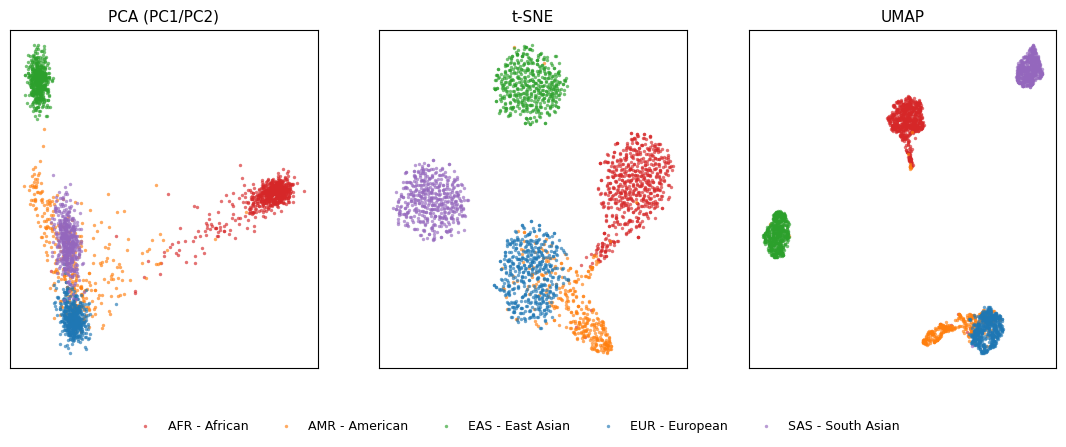

silhouette         5 super-pops  26 populations
PCA (PC1/PC2)             0.588          -0.127


t-SNE                     0.591          -0.058


UMAP                      0.712          -0.075


In [11]:
embeddings = [("PCA (PC1/PC2)", Zp[:, :2]), ("t-SNE", Zt), ("UMAP", Zu)]
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.4))
for ax, (name, Zx) in zip(axes, embeddings):
    for s in sorted(SUPER_NAMES):
        m = sup == s
        ax.scatter(Zx[m, 0], Zx[m, 1], s=6, alpha=0.65, color=SUPER_COLORS[s],
                   linewidths=0, label=f"{s} - {SUPER_NAMES[s]}")
    ax.set_title(name, fontsize=11)
    ax.set_xticks([]); ax.set_yticks([])
fig.legend(*axes[0].get_legend_handles_labels(), ncol=5, frameon=False,
           loc="lower center", bbox_to_anchor=(0.5, -0.06), fontsize=9)
plt.show()

print(f"silhouette        {'5 super-pops':>13} {'26 populations':>15}")
for name, Zx in embeddings:
    print(f"{name:<17} {silhouette_score(Zx, sup):>13.3f} {silhouette_score(Zx, pop):>15.3f}")

Three readings, in the order the numbers force them:

1. **UMAP "wins"** — the crispest continents (silhouette 0.71 vs PCA's 0.59).
2. **But the prettiest map is not the truest.** PCA's orange smear was *real admixture* — a
   continuum. UMAP compressed that continuum into a tongue stuck to the European island; the
   in-between-ness is mostly gone. Crispness manufactured discreteness. (The same complaint is
   published about single-cell biology: Chari & Pachter, *The specious art of single-cell
   genomics*, PLOS Comp Bio 2023.)
3. **The 26 fine populations separate in NO 2-D map** — every silhouette in that column is
   negative. Fine structure needs genome-wide data; chr22 does not carry it, and an honest
   negative number beats a hopeful picture.

And one lecture-36 callback you can now check by eye: the *distances between* UMAP's islands
mean nothing — you cannot ask "is South Asia genetically closer to East Asia or to Europe?"
from the UMAP panel. From PCA, you can.

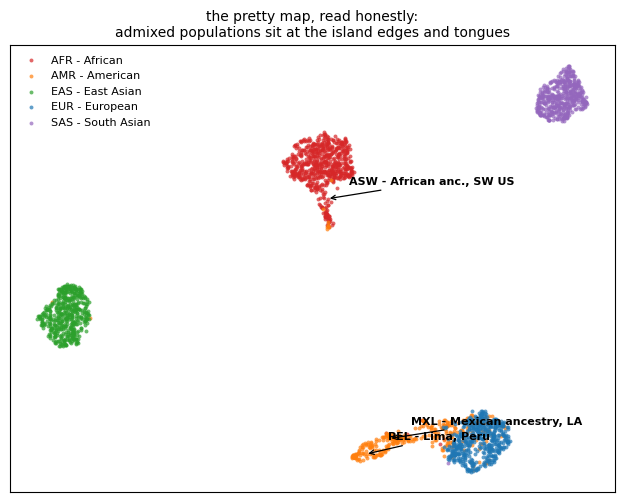

In [12]:
fig, ax = plt.subplots(figsize=(7.8, 5.8))
for s in sorted(SUPER_NAMES):
    m = sup == s
    ax.scatter(Zu[m, 0], Zu[m, 1], s=8, alpha=0.7, color=SUPER_COLORS[s], linewidths=0,
               label=f"{s} - {SUPER_NAMES[s]}")
for c26, label in [("PEL", "PEL - Lima, Peru"), ("MXL", "MXL - Mexican ancestry, LA"),
                   ("ASW", "ASW - African anc., SW US")]:
    med = np.median(Zu[pop == c26], axis=0)
    ax.annotate(label, med, textcoords="offset points", xytext=(16, 10), fontsize=8,
                fontweight="bold", arrowprops=dict(arrowstyle="->", lw=0.9))
ax.set_xticks([]); ax.set_yticks([])
ax.legend(frameon=False, fontsize=8)
ax.set_title("the pretty map, read honestly:\nadmixed populations sit at the island edges and tongues",
             fontsize=10)
plt.show()

## Act 5 - PCA as preprocessing: how many components does a *model* need?

So far the components fed our eyes. The deck promised a second job: **preprocessing** - hand
a model a few scores instead of 16,202 raw columns. Two questions, in order:

1. How much variance do the leading components even hold - the **scree / explained-variance**
   view?
2. Does a classifier actually lose anything when we throw the other ~16,000 directions away?

**Predict first:** PC1+PC2 drew the entire continental structure in Act 1. What share of the
total variance do those two directions hold - half? More?


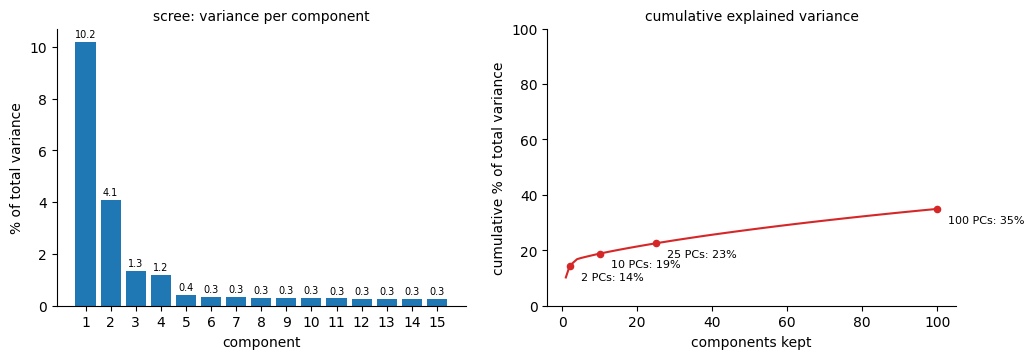

In [13]:
Z100, evr100 = pca_scores(X, n=100)            # Act 1's function, just more components
cum = evr100.cumsum()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.6, 3.6))
bars = ax1.bar(range(1, 16), evr100[:15] * 100, color="tab:blue")
ax1.bar_label(bars, fmt="%.1f", fontsize=7, padding=2)
ax1.set_xticks(range(1, 16))
ax1.set_xlabel("component"); ax1.set_ylabel("% of total variance")
ax1.set_title("scree: variance per component", fontsize=10)

ax2.plot(range(1, 101), cum * 100, color="tab:red")
for k in (2, 10, 25, 100):
    ax2.scatter([k], [cum[k - 1] * 100], s=20, color="tab:red")
    ax2.annotate(f"{k} PCs: {cum[k-1]*100:.0f}%", (k, cum[k - 1] * 100),
                 textcoords="offset points", xytext=(8, -10), fontsize=8)
ax2.set_ylim(0, 100)
ax2.set_xlabel("components kept"); ax2.set_ylabel("cumulative % of total variance")
ax2.set_title("cumulative explained variance", fontsize=10)
for ax in (ax1, ax2):
    ax.spines[["top", "right"]].set_visible(False)
plt.show()


**PC1 + PC2 hold 14% of the variance.** The two directions that painted the whole
continental picture carry a *seventh* of the total - and even 100 components stop near a
third. That is not a failure: most of these 16,202 columns are individually patternless, so
most of the total variance is unstructured noise that no few directions can absorb.
**Explained variance measures reconstruction, not usefulness.** A "keep 95%" rule - which
cost 184 of 784 components on the garments - would demand thousands of components here and
buy nothing.

Which is why the deck's rule was: when PCA feeds a model, choose $k$ on the **downstream
metric**, with the PCA fit inside the training fold. So let's measure the downstream metric -
hold 500 of the 2,504 people out as a test set, fit everything on the other
2,004, and try the course's two workhorse classifiers - logistic regression and a
random forest:


In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.exceptions import ConvergenceWarning
import warnings
warnings.filterwarnings("ignore", category=ConvergenceWarning)
# Not swallowed silently: below we read each fit's n_iter_ and mark every fit that
# stopped at the 1,000-iteration cap with a * - same information, less scrolling.

idx6 = np.random.default_rng(SEED).permutation(len(X))   # fresh generator: reruns reproduce
te6, tr6 = idx6[:500], idx6[500:]
p6 = X[tr6].astype(np.float32).mean(axis=0) / 2
keep6 = (p6 > 0) & (p6 < 1)                              # Act 3's lesson is a habit now

def scale6(A):
    A = A.astype(np.float32)
    return (A[:, keep6] - 2 * p6[keep6]) / np.sqrt(p6[keep6] * (1 - p6[keep6]))

Xtr6, Xte6 = scale6(X[tr6]), scale6(X[te6])

feat_sets = {"all 16,202 SNPs": (Xtr6, Xte6)}
for k in (2, 10, 25):
    pca = PCA(n_components=k, random_state=SEED).fit(Xtr6)     # fit on TRAIN only (leakage rule)
    feat_sets[f"{k} PCs"] = (pca.transform(Xtr6), pca.transform(Xte6))

targets = (("super-population (5 classes)", sup), ("population (26 classes)", pop))
models = {"logistic regression": lambda: LogisticRegression(max_iter=1000),
          "random forest": lambda: RandomForestClassifier(n_estimators=200,
                                                          random_state=SEED, n_jobs=4)}
results = {}
for tname, y in targets:
    for fname, (Ztr6, Zte6) in feat_sets.items():
        for mname, make in models.items():
            t0 = time.perf_counter()
            m = make().fit(Ztr6, y[tr6])
            sec = time.perf_counter() - t0
            capped = getattr(m, "n_iter_", np.zeros(1)).max() >= 1000
            results[(tname, fname, mname)] = (m.score(Zte6, y[te6]), sec, capped)
            print(f"{tname:<28} {fname:<16} {mname:<20} "
                  f"{results[(tname, fname, mname)][0]:6.1%}{'*' if capped else ' '} ({sec:4.1f}s)")


super-population (5 classes) all 16,202 SNPs  logistic regression   97.2%  ( 1.2s)


super-population (5 classes) all 16,202 SNPs  random forest         94.6%  ( 2.7s)
super-population (5 classes) 2 PCs            logistic regression   87.2%  ( 0.2s)


super-population (5 classes) 2 PCs            random forest         88.8%  ( 0.4s)


super-population (5 classes) 10 PCs           logistic regression   96.2%  ( 0.4s)


super-population (5 classes) 10 PCs           random forest         96.0%  ( 0.5s)


...

population (26 classes)      2 PCs            random forest         25.4%  ( 0.6s)


population (26 classes)      10 PCs           logistic regression   37.0%* ( 1.5s)


population (26 classes)      10 PCs           random forest         37.4%  ( 1.3s)


population (26 classes)      25 PCs           logistic regression   41.6%* ( 1.9s)


population (26 classes)      25 PCs           random forest         43.6%  ( 2.1s)


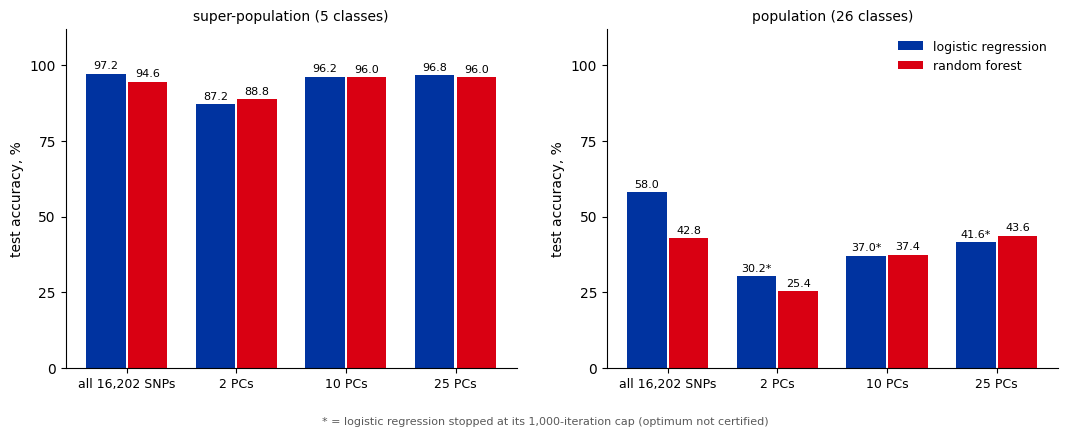

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.4))
colors = {"logistic regression": "#0033A0", "random forest": "#D90012"}
for ax, (tname, _) in zip(axes, targets):
    xpos = np.arange(len(feat_sets))
    for j, mname in enumerate(models):
        accs = [results[(tname, f, mname)][0] * 100 for f in feat_sets]
        caps = ["*" if results[(tname, f, mname)][2] else "" for f in feat_sets]
        b = ax.bar(xpos + (j - 0.5) * 0.38, accs, 0.36, color=colors[mname], label=mname)
        ax.bar_label(b, labels=[f"{a:.1f}{c}" for a, c in zip(accs, caps)], fontsize=8, padding=2)
    ax.set_xticks(xpos); ax.set_xticklabels(list(feat_sets), fontsize=9)
    ax.set_ylim(0, 112); ax.set_yticks((0, 25, 50, 75, 100))
    ax.set_ylabel("test accuracy, %")
    ax.set_title(tname, fontsize=10)
    ax.spines[["top", "right"]].set_visible(False)
axes[1].legend(frameon=False, fontsize=9, loc="upper right")
fig.text(0.5, -0.02, "* = logistic regression stopped at its 1,000-iteration cap (optimum not certified)",
         ha="center", fontsize=8, color="0.35")
plt.show()


Reading the chart:

1. **25 numbers per person do the work of 16,202** on the continental target - for both
   models. Logistic regression: 96.8% vs 97.2%, with 125 coefficients to learn instead of
   81,010 (roughly **650x fewer**). The deck's preprocessing promise, measured.
2. **The forest liked the rotation.** On the raw SNPs the forest trails (94.6%): a tree
   splits on one feature at a time, and no single SNP is worth splitting on. Rotate with PCA
   and whole ancestry gradients become single axes - the forest jumps to 96.0% with just 10
   of them. The deck said "tree models usually do not need DR"; measured here, PCA did not
   just shrink the forest's input 650-fold, it *helped*.
3. **The starred bars** are the fits that stopped at the 1,000-iteration cap - that is the
   `ConvergenceWarning` the raw output would have spammed; we silence it and read each fit's
   `n_iter_` instead (same information, one `*`). Note where they sit: the 26-class logistic
   fits on *PC* features. The wide 16,202-column fits converge in under 20 iterations - the
   default L2 penalty keeps even a linearly-separable problem well-posed; it is 26
   heavily-overlapping classes squeezed into a few dimensions that leave the optimizer
   grinding. A cap means "optimum not certified", not "accuracy is wrong" - but always check
   *which* fit raised it.
4. **The honest counterpoint** - the deck's "when NOT to reduce" frame: for the 26
   fine-grained populations, the linear model on all 16,202 SNPs reaches 58% while nothing
   on 25 PCs passes 44%. Part of the fine signal lives in directions PCA ranked low-variance
   and threw away. And the forest on raw SNPs (42.8%) is lesson 2's mirror image: signal
   spread thinly over thousands of weak columns is exactly what one-feature-at-a-time splits
   cannot collect - and exactly what a linear sum can. DR is a trade; tune $k$ on the
   downstream metric.


## Act 6 - then why not feed t-SNE or UMAP coordinates to the model?

Act 4 crowned UMAP the crispest picture (silhouette 0.71 vs PCA's 0.59), and the deck's red
box still insists: *"do not feed the 2-D embedding to a downstream model - it is for the
eyes."* Let's disobey carefully and watch exactly where it breaks.

**Predict first:** logistic regression on 2 PCs scored 87% in the Act 5 chart. UMAP's
islands are much crisper - what will logistic regression on 2 UMAP coordinates score?


In [16]:
print(f"does a fitted t-SNE have .transform? {hasattr(TSNE, 'transform')}")

# So t-SNE "features" are only possible by fitting on ALL 2,504 people - test included.
# We already have exactly that: Act 4's cached embedding. Use it and keep a straight face:
lr_leak = LogisticRegression(max_iter=1000).fit(Zt[tr6], sup[tr6])
print(f"t-SNE-2 'features', fit on everyone: 'test' accuracy {lr_leak.score(Zt[te6], sup[te6]):.1%}"
      "  <- leaked: the test people helped draw the map\n")

# UMAP does have transform, so IT can play honestly: fit on train only, transform the test.
import warnings
warnings.filterwarnings("ignore", message="IProgress not found")   # cosmetic tqdm notice
import umap

pca25 = PCA(n_components=25, random_state=SEED).fit(Xtr6)   # the lecture recipe, train-only
Ptr, Pte = pca25.transform(Xtr6), pca25.transform(Xte6)
um_a = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=SEED).fit(Ptr)
Ute_a = um_a.transform(Pte)
lr_um = LogisticRegression(max_iter=1000).fit(um_a.embedding_, sup[tr6])
acc_um = lr_um.score(Ute_a, sup[te6])

pc2_a = PCA(n_components=2, random_state=SEED).fit(Xtr6)
Zp2_te = pc2_a.transform(Xte6)
lr_p2 = LogisticRegression(max_iter=1000).fit(pc2_a.transform(Xtr6), sup[tr6])
acc_p2 = lr_p2.score(Zp2_te, sup[te6])
print(f"honest protocol, 2 features each:  UMAP-2 {acc_um:.1%}   PCA-2 {acc_p2:.1%}")


does a fitted t-SNE have .transform? False
t-SNE-2 'features', fit on everyone: 'test' accuracy 95.2%  <- leaked: the test people helped draw the map



C:\Users\hayk_\OneDrive\Desktop\01_python_math_ml_course\ma\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


honest protocol, 2 features each:  UMAP-2 94.6%   PCA-2 87.2%


**UMAP won the 2-feature contest** - crisper islands really are easier to cut with a
linear classifier, and `transform` made the protocol honest. Two cracks are showing anyway:
t-SNE could only play by cheating, and the Act 5 chart says plain **10 PCs score 96.2%** -
the two-feature bottleneck is something we imposed for pictures, not something a model wants.

But the real test is the one production runs every week: **the pipeline refits.** Say 100 of
the 2,004 training people withdraw their consent; rebuild everything - scaling, PCA, UMAP -
same code, same seeds. Then let *yesterday's* classifier read *today's* coordinates:


C:\Users\hayk_\OneDrive\Desktop\01_python_math_ml_course\ma\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


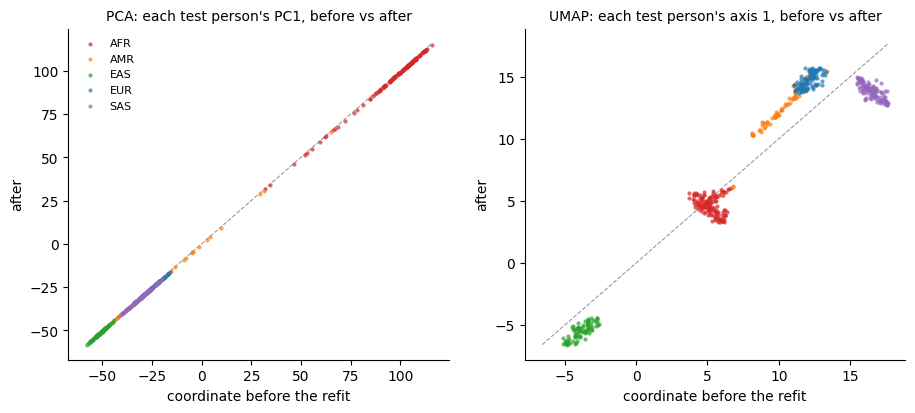

mean |coordinate change| / spread:   PCA 0.9%   UMAP 43.4%
yesterday's classifier on today's coordinates:
   PCA-2   87.4%  (was 87.2%)
   UMAP-2  87.0%  (was 94.6%)


In [17]:
tr6b = tr6[100:]                                   # same pipeline, 100 fewer people
p6b = X[tr6b].astype(np.float32).mean(axis=0) / 2
keep6b = (p6b > 0) & (p6b < 1)

def scale6b(A):
    A = A.astype(np.float32)
    return (A[:, keep6b] - 2 * p6b[keep6b]) / np.sqrt(p6b[keep6b] * (1 - p6b[keep6b]))

Xtr6b, Xte6b = scale6b(X[tr6b]), scale6b(X[te6])
pca25_b = PCA(n_components=25, random_state=SEED).fit(Xtr6b)
um_b = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=SEED).fit(pca25_b.transform(Xtr6b))
Ute_b = um_b.transform(pca25_b.transform(Xte6b))
pc2_b = PCA(n_components=2, random_state=SEED).fit(Xtr6b)
Zp2b_te = pc2_b.transform(Xte6b)

fig, axes = plt.subplots(1, 2, figsize=(10.8, 4.3))
for ax, A, B, t in ((axes[0], Zp2_te[:, 0], Zp2b_te[:, 0], "PCA: each test person's PC1, before vs after"),
                    (axes[1], Ute_a[:, 0], Ute_b[:, 0], "UMAP: each test person's axis 1, before vs after")):
    lo, hi = min(A.min(), B.min()), max(A.max(), B.max())
    ax.plot([lo, hi], [lo, hi], ls="--", lw=0.8, color="0.6", zorder=0)   # y = x: unchanged
    for s in sorted(SUPER_NAMES):
        m = sup[te6] == s
        ax.scatter(A[m], B[m], s=9, alpha=0.7, color=SUPER_COLORS[s], linewidths=0, label=s)
    ax.set_xlabel("coordinate before the refit"); ax.set_ylabel("after")
    ax.set_title(t, fontsize=10)
    ax.spines[["top", "right"]].set_visible(False)
axes[0].legend(frameon=False, fontsize=8)
plt.show()

shift_p = np.abs(Zp2b_te - Zp2_te).mean() / np.abs(Zp2_te - Zp2_te.mean(0)).mean()
shift_u = np.abs(Ute_b - Ute_a).mean() / np.abs(Ute_a - Ute_a.mean(0)).mean()
print(f"mean |coordinate change| / spread:   PCA {shift_p:.1%}   UMAP {shift_u:.1%}")
print("yesterday's classifier on today's coordinates:")
print(f"   PCA-2   {lr_p2.score(Zp2b_te, sup[te6]):.1%}  (was {acc_p2:.1%})")
print(f"   UMAP-2  {lr_um.score(Ute_b, sup[te6]):.1%}  (was {acc_um:.1%})")


Three ways it broke, none of them subtle:

1. **t-SNE never entered.** There is no `transform`: the only way to hand the model t-SNE
   "features" was to fit on everyone - test people included - and the ~95% it printed is a
   **leaked** number no deployed model could reproduce. (The decision table's "New points?
   no", turned into a scoreboard.)
2. **The 2-feature contest was rigged in UMAP's favor anyway.** Honest UMAP-2 did beat
   PCA-2, 94.6% to 87.2% - but a model is not stuck with 2 inputs. Plain 10 PCs already
   score 96.2% (Act 5), cost seconds, and skip the extra dependency. The 2-D bottleneck
   exists for *eyes*, not for models.
3. **The refit killed it.** Losing 100 of 2,004 people moved UMAP's coordinates by ~43% of
   their spread (right panel: the islands physically relocated) and dropped yesterday's
   classifier from 94.6% to 87.0% - the entire advantage, gone on the first routine refresh.
   PCA's coordinates moved by ~1% and the classifier did not notice (87.2% -> 87.4%). PCA's
   axes are *eigenvectors of the data* - almost the same data gives almost the same axes (up
   to a sign flip you can see and fix). A UMAP layout is the endpoint of a stochastic
   optimization: a **picture** of the data, not a coordinate system on it.

The deck's caveat, now with numbers on it: **embeddings are pictures. Models get PCs.**


## Wrap-up

| you can trust | you cannot trust |
|---|---|
| PC1/PC2 = ancestry structure (variance found it, unsupervised) | 2-D distances *between* UMAP/t-SNE islands |
| the admixture smears in PCA - they are real history | crisp island boundaries - they can manufacture discreteness |
| projecting *new* people onto fixed PCs | 26-population "clusters" - silhouettes are negative, don't narrate them |
| top-$k$ PC scores as model inputs, axes fit on the training fold (Act 5) | t-SNE/UMAP coordinates as model inputs (Act 6) - no map for new people, and the map moves on every refit |
| the north-south signal in Europe (medians) | Spain-vs-Italy stories at this resolution |

One careful closing note for the room: these principal components are **continuous gradients
shaped by migration and drift**, not categories - the picture argues *against* discrete
"races", not for them; the smears and tongues are the point.

**References.** Novembre et al., [*Genes mirror geography within Europe*](https://www.ncbi.nlm.nih.gov/pmc/articles/PMC2735096/), Nature 2008 (1,387 people, ~197k QC'd SNPs, POPRES) ·
[1000 Genomes phase 3](https://www.internationalgenome.org/) (open data; [population codes](https://ftp.1000genomes.ebi.ac.uk/vol1/ftp/README_populations.md)) ·
Patterson, Price & Reich, *Population structure and eigenanalysis*, PLoS Genetics 2006 ·
Chari & Pachter, [*The specious art of single-cell genomics*](https://journals.plos.org/ploscompbiol/article?id=10.1371/journal.pcbi.1011288), PLOS Comp Bio 2023.
Data prep: `py_src/fetch_1000g_genotypes.py`; validation record: `py_src/non_essential/validate_genes_geography.py`, DECISIONS.md #32.

## Coda - the picture we were chasing

This is the actual Figure 1 of Novembre et al. (2008): 1,387 Europeans, ~197k SNPs after
quality control, sampled country by country - and PC1/PC2 (rotated by $-16^\circ$, panel a)
redraw the map of Europe. The small colored inset *is* the map; the scatter is pure genetics.
Same algorithm we ran today - the extra resolution came from the sampling design and from
12x more SNPs, not from better math.

<img src="fig/borrowed/novembre2008_fig1.jpg" width="620">

*Novembre et al., "Genes mirror geography within Europe", Nature 456, 98-101 (2008), Figure 1.*
